In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pylab as pl

from cgt_perezsechi.visualization.plot import plot_shap_distribution
from cgt_perezsechi.modeling.inequality import gini_coefficient
# from cgt_perezsechi.visualization.plot import plot_shap_lorenz_curve

In [2]:
X = pd.read_pickle("../../data/shap/x_values.pkl")
num_patients = 500
X_shapley = X.iloc[:num_patients, :]
shap_values = np.load("../../data/shap/shap_values.npy")
shap_interaction_values = np.load("../../data/shap/shap_interaction_values.npy")

In [3]:
n_bins = 100

## Distribución con respecto a la suma parcial de las variables

In [6]:
top_variables = [
    "age",
    "sex_isFemale",
    "systolic_blood_pressure",
    # "bmi",
    # "urine_albumin_isNegative",
    # "pulse_pressure",
    # "rand"
]

Variable: age


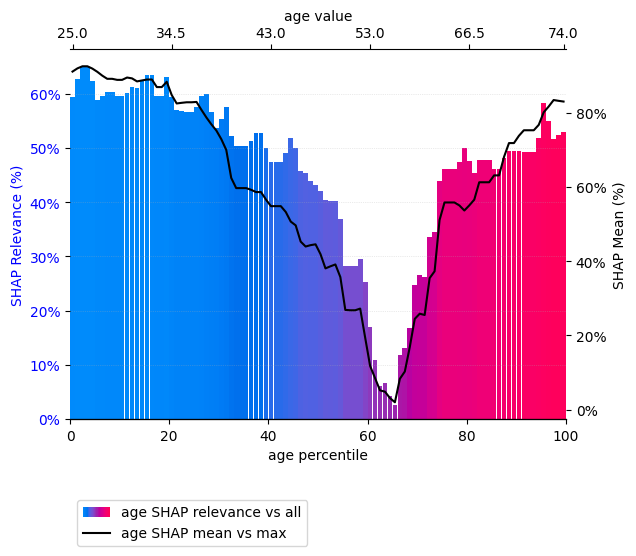

Minimum relevance where age equals 56.170000000000016
Variable: sex_isFemale


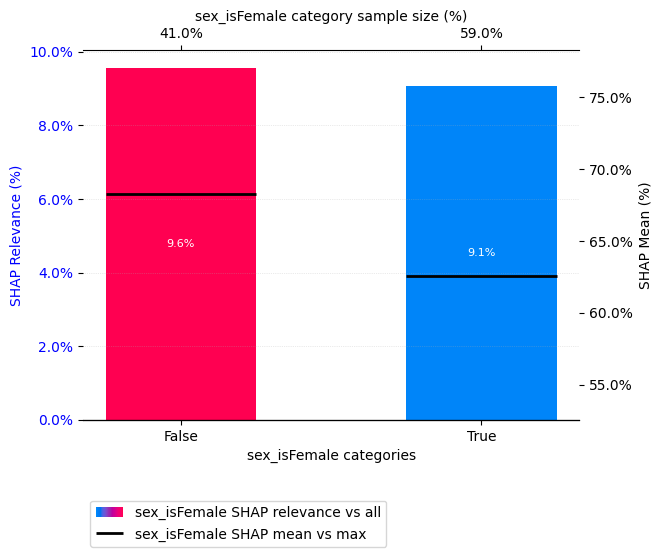

Minimum relevance where sex_isFemale equals 59.0%
Variable: systolic_blood_pressure


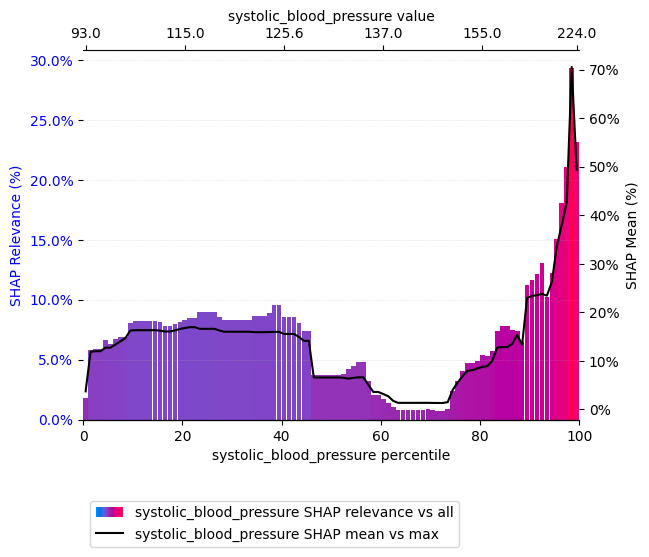

Minimum relevance where systolic_blood_pressure equals 144.0


In [5]:
for variable_name in top_variables:
    print(f"Variable: {variable_name}")
    results = plot_shap_distribution(variable_name, X_shapley, shap_values, n_bins)
    min_index = np.argmin(results["abs_shap_relevance"])
    print(f"Minimum relevance where {variable_name} equals {results['variable_label'][min_index]}")

In [4]:
import shap
import matplotlib.ticker as mtick


def shap_acumulated_importance_value(
    X_variable,
    variable_shap_values,
    starting_percentile,
    ending_percentile
):
    starting_percentile_value = np.percentile(variable_shap_values, starting_percentile)
    ending_percentile_value = np.percentile(variable_shap_values, ending_percentile)
    idx_survivors_percentile = np.where(
        (variable_shap_values >= starting_percentile_value) &
        (variable_shap_values <= ending_percentile_value)
    )[0]
    idx_survivors_accumulated = np.where(
        variable_shap_values <= ending_percentile_value
    )[0]

    percentile_shap_values = variable_shap_values[idx_survivors_accumulated]
    percentile_x_values = X_variable.iloc[idx_survivors_percentile]

    return {
        "percentile_shap_values": percentile_shap_values,
        "percentile_x_values": percentile_x_values,
    }

def plot_shap_lorenz_curve(variable_name, X, shap_values, n_bins):
    bins = np.arange(n_bins)
    X_variable = X[variable_name]

    lorenz_values = np.zeros(n_bins)
    mean_x_values = np.zeros(n_bins)
    variable_index = X.columns.get_loc(variable_name)
    variable_shap_values = shap_values[:, variable_index]
    shap_sum = np.sum(shap_values[:, variable_index])

    for i in bins:
        starting_percentile = i * 100 / n_bins
        ending_percentile = (i + 1) * 100 / n_bins
        result = shap_acumulated_importance_value(
            X_variable,
            variable_shap_values,
            starting_percentile,
            ending_percentile
        )
        lorenz_values[i] = 100 * np.sum(result["percentile_shap_values"]) / shap_sum
        mean_x_values[i] = np.mean(result["percentile_x_values"])

    _, ax = pl.subplots()

    cmap = shap.plots.colors._colors.red_blue

    norm_shap_mean = (mean_x_values - np.min(mean_x_values)) / \
        (np.max(mean_x_values) - np.min(mean_x_values))
    colors = cmap(norm_shap_mean)

    ax.bar(
        bins * 100 / n_bins, lorenz_values, color=colors
    )
    ax.plot(bins * 100 / n_bins, bins * 100 / n_bins, color="green")

    pl.legend([
        f"Perfect equality",
        f"Accumulated SHAP"
    ])
    pl.xlabel(f"SHAP percentile")
    pl.ylabel(f"Percentage")
    pl.title(f"{variable_name} SHAP Lorenz curve")

    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    pl.show()

Gini coefficient for age SHAP values: 0.4433


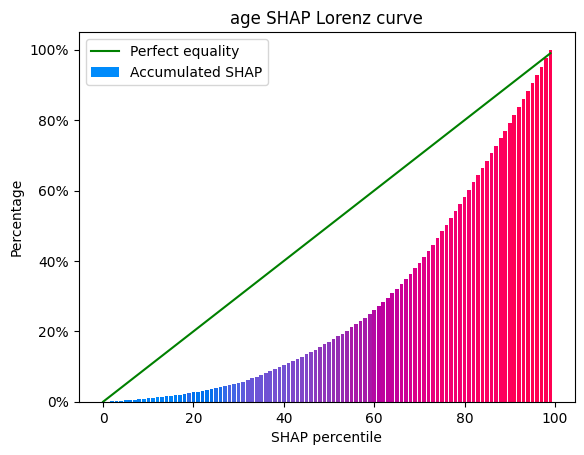

Gini coefficient for sex_isFemale SHAP values: 0.0633


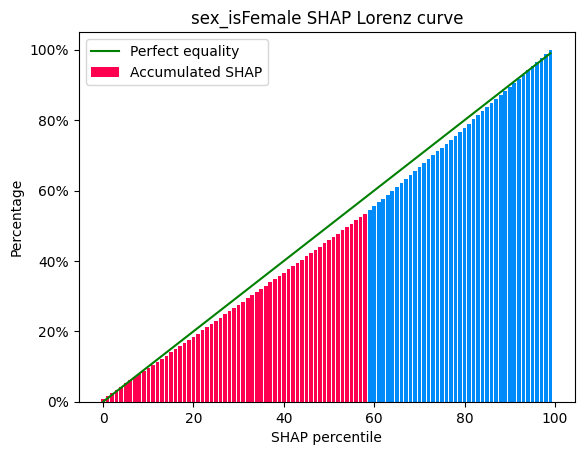

Gini coefficient for systolic_blood_pressure SHAP values: 0.0572


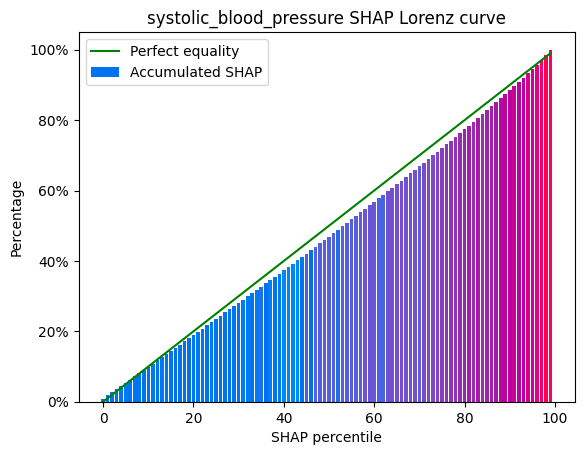

In [7]:
norm_shap_values = (shap_values - np.min(shap_values)) / \
    (np.max(shap_values) - np.min(shap_values))
abs_shap_values = np.abs(shap_values)

for variable_name in top_variables:
    variable_index = X_shapley.columns.get_loc(variable_name)
    variable_shap_values = norm_shap_values[:, variable_index]

    gini_index = gini_coefficient(variable_shap_values)
    print(f"Gini coefficient for {variable_name} SHAP values: {gini_index:.4f}")
    plot_shap_lorenz_curve(variable_name, X_shapley, norm_shap_values, n_bins)